#Question - 3


## a) my_map()

In [20]:
import numpy as np
import sklearn

def my_map(X):

    # Transforming {0, 1} to {-1, 1}
    # Here, X_transformed will have the same shape as X, but with values in {-1, 1} instead of {0, 1}
    X_transformed = 1-2*X


    X_even = X_transformed[:, 0::2]  # Nx16 shaped vector consisting of the even indexed features (0, 2, 4, ..., 30)
    X_odd = X_transformed[:, 1::2]   # Nx16 shaped vector consisting of the odd indexed features (1, 3, 5, ..., 31)


    # # Computing the pair-wise products for the final expression
    pairwise_products = (X_even[:, :, None] * X_odd[:, None, :]).reshape(X.shape[0], -1)  # Final shape: Nx256

    # Stacking the pairwise products with the original features to get the final mapped vector
    X_map = np.hstack((pairwise_products, X_even, X_odd))  # Final shape: Nx288 (288 is the dimension "D" from part2)

    # TRANSFORMED VECTOR: [ x1*x2  x1*x3 ... x1*x32  x2*x3 x2*x4 ... x31*x32 | x0 x2 ... x32 | x1 x3 ... x31 ]
    # Structure of the vector: [ PAIRWISE PRODUCTS(16x16=256) | EVEN(16) | ODD(16) ]

    return X_map

In [21]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

##b) my_params()

###Loading Data

In [22]:
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import time

trn = np.loadtxt('public_trn.txt', dtype=int)
tst = np.loadtxt('public_tst.txt', dtype=int)

X_trn, y_trn = trn[:, :32], trn[:, 32]
X_tst, y_tst = tst[:, :32], tst[:, 32]

###Applying my_map()

In [23]:
X_trn_map = my_map(X_trn)
X_tst_map = my_map(X_tst)
print(X_trn_map.shape)

(7500, 288)


###Test Train Split

In [24]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_trn_map, y_trn,
    test_size=0.2,
    random_state=42
)

###Experimenting Hyperparameters

In [25]:
print(f"{'C':<8} {'loss':<18} {'tol':<8} {'Val Acc':>8} {'Tst Acc':>8} {'Time':>7}")

for C in [0.1, 0.5, 1.0, 5.0, 10.0]:
    for loss in ['hinge', 'squared_hinge']:
        for tol in [1e-2, 1e-3, 1e-4]:
            clf = LinearSVC(C=C, loss=loss, tol=tol,
                           max_iter=5000, dual='auto')
            t0 = time.time()
            clf.fit(X_tr, y_tr)
            t = time.time() - t0

            val_acc = accuracy_score(y_val, clf.predict(X_val))
            tst_acc = accuracy_score(y_tst, clf.predict(X_tst_map))

            print(f"{C:<8} {loss:<18} {tol:<8} "
                  f"{val_acc*100:>7.2f}% {tst_acc*100:>7.2f}% {t:>6.3f}s")

C        loss               tol       Val Acc  Tst Acc    Time
0.1      hinge              0.01       99.67%   99.56%  1.117s


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.1      hinge              0.001      99.73%   99.60%  2.396s


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.1      hinge              0.0001     99.67%   99.56%  3.043s
0.1      squared_hinge      0.01       99.73%   99.72%  0.289s
0.1      squared_hinge      0.001      99.73%   99.72%  0.262s
0.1      squared_hinge      0.0001     99.73%   99.72%  0.289s


...

10.0     hinge              0.01       99.53%   99.36%  1.500s


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


10.0     hinge              0.001      99.47%   99.28%  1.483s


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


10.0     hinge              0.0001     99.60%   99.44%  1.498s
10.0     squared_hinge      0.01       99.73%   99.52%  0.218s
10.0     squared_hinge      0.001      99.67%   99.40%  0.331s
10.0     squared_hinge      0.0001     99.60%   99.44%  0.712s


###Training and Testing on Full Dataset using L1 Penalty (Slower)

In [26]:

X_trn_map = my_map(X_trn)
X_tst_map = my_map(X_tst)

clf = LinearSVC(penalty='l1', loss='squared_hinge', dual='auto', tol=0.0001, C=1.0, multi_class='ovr', fit_intercept=True, intercept_scaling=1, class_weight=None, verbose=0, random_state=None, max_iter=1000)
clf.fit(X_trn_map, y_trn)

print("Train:", accuracy_score(y_trn, clf.predict(X_trn_map)))
print("Test: ", accuracy_score(y_tst, clf.predict(X_tst_map)))

Train: 1.0
Test:  0.9988


###Training and Testing on Full Dataset using L2 Penalty (Faster)

In [27]:

X_trn_map = my_map(X_trn)
X_tst_map = my_map(X_tst)

clf = LinearSVC(C=0.5, loss='squared_hinge', tol=0.01, max_iter=5000, dual='auto')
clf.fit(X_trn_map, y_trn)

print("Train:", accuracy_score(y_trn, clf.predict(X_trn_map)))
print("Test: ", accuracy_score(y_tst, clf.predict(X_tst_map)))

Train: 0.9992
Test:  0.9988


### Speed Comparison between L1 and L2 Penalty

In [28]:
import time

# L1 version
t0 = time.time()
clf1 = LinearSVC(penalty='l1', loss='squared_hinge',
                 dual=False, tol=0.0001, C=1.0, max_iter=1000)
clf1.fit(X_trn_map, y_trn)
print(f"L1 time: {time.time()-t0:.3f}s")

# Previous L2 version
t0 = time.time()
clf2 = LinearSVC(penalty='l2', loss='squared_hinge',
                 dual='auto', tol=0.01, C=0.5, max_iter=5000)
clf2.fit(X_trn_map, y_trn)
print(f"L2 time: {time.time()-t0:.3f}s")

L1 time: 9.280s
L2 time: 0.233s


###Final my_params() function (To be Included in the submit.py file)

In [29]:
def my_params(X_map, X_raw, y):
    return {
        "loss"     : "squared_hinge",
        "C"        : 0.5,
        "tol"      : 0.01,
        "dual"     : "auto",
        "max_iter" : 5000,
    }

#Question - 4

##Loss Comparison

In [30]:
print(f"{'Loss':<20} {'Train Acc':>10} {'Test Acc':>10} {'Time':>10}")
for loss in ['hinge', 'squared_hinge']:
    clf = LinearSVC(C=0.5, loss=loss, tol=0.01,
                    max_iter=10000, dual='auto')
    t0 = time.time()
    clf.fit(X_trn_map, y_trn)
    t = time.time() - t0
    tr = accuracy_score(y_trn, clf.predict(X_trn_map))
    ts = accuracy_score(y_tst, clf.predict(X_tst_map))
    print(f"{loss:<20} {tr*100:>9.2f}% {ts*100:>9.2f}% {t:>9.3f}s")

Loss                  Train Acc   Test Acc       Time
hinge                    99.88%     99.80%     0.948s
squared_hinge            99.92%     99.88%     0.250s


# C values

In [31]:
import time

print("LinearSVC:")
print(f"{'C':<10} {'Train Acc':>10} {'Test Acc':>10} {'Time(s)':>10}")

for C in [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]:
    clf = LinearSVC(
        C=C,
        loss='squared_hinge',
        tol=0.01,
        max_iter=5000,
        dual='auto'
    )

    t0 = time.time()
    clf.fit(X_trn_map, y_trn)
    t = time.time() - t0

    tr = accuracy_score(y_trn, clf.predict(X_trn_map))
    ts = accuracy_score(y_tst, clf.predict(X_tst_map))

    print(f"{C:<10} {tr*100:>9.2f}% {ts*100:>9.2f}% {t:>9.3f}")

print("\nLogisticRegression:")
print(f"{'C':<10} {'Train Acc':>10} {'Test Acc':>10} {'Time(s)':>10}")

for C in [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]:
    clf = LogisticRegression(
        C=C,
        max_iter=5000,
        tol=0.01
    )

    t0 = time.time()
    clf.fit(X_trn_map, y_trn)
    t = time.time() - t0

    tr = accuracy_score(y_trn, clf.predict(X_trn_map))
    ts = accuracy_score(y_tst, clf.predict(X_tst_map))

    print(f"{C:<10} {tr*100:>9.2f}% {ts*100:>9.2f}% {t:>9.3f}")

LinearSVC:
C           Train Acc   Test Acc    Time(s)
0.001          98.55%     96.80%     0.193
0.01           99.68%     98.72%     0.261
0.1            99.93%     99.80%     0.237
0.5            99.92%     99.88%     0.255
1.0            99.95%     99.88%     0.250
5.0            99.97%     99.88%     0.259
10.0           99.97%     99.88%     0.244

LogisticRegression:
C           Train Acc   Test Acc    Time(s)
0.001          95.73%     93.56%     0.019
0.01           97.19%     95.76%     0.025
0.1            99.23%     98.16%     0.056
0.5            99.25%     98.16%     0.048
1.0            99.25%     98.16%     0.061
5.0            99.25%     98.12%     0.066
10.0           99.25%     98.12%     0.069


#Tolerance

In [32]:
import time

print("LinearSVC:")
print(f"{'tol':<12} {'Train Acc':>10} {'Test Acc':>10} {'Time(s)':>10}")

for tol in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]:
    clf = LinearSVC(
        C=0.5,
        loss='squared_hinge',
        tol=tol,
        max_iter=5000,
        dual='auto'
    )

    t0 = time.time()
    clf.fit(X_trn_map, y_trn)
    t = time.time() - t0

    tr = accuracy_score(y_trn, clf.predict(X_trn_map))
    ts = accuracy_score(y_tst, clf.predict(X_tst_map))

    print(f"{tol:<12} {tr*100:>9.2f}% {ts*100:>9.2f}% {t:>9.3f}")

print("\nLogisticRegression:")
print(f"{'tol':<12} {'Train Acc':>10} {'Test Acc':>10} {'Time(s)':>10}")

for tol in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]:
    clf = LogisticRegression(
        C=0.5,
        tol=tol,
        max_iter=5000
    )

    t0 = time.time()
    clf.fit(X_trn_map, y_trn)
    t = time.time() - t0

    tr = accuracy_score(y_trn, clf.predict(X_trn_map))
    ts = accuracy_score(y_tst, clf.predict(X_tst_map))

    print(f"{tol:<12} {tr*100:>9.2f}% {ts*100:>9.2f}% {t:>9.3f}")

LinearSVC:
tol           Train Acc   Test Acc    Time(s)
0.1              99.17%     98.16%     0.190
0.01             99.92%     99.88%     0.237
0.001            99.99%     99.84%     0.286
0.0001           99.99%     99.84%     0.287
1e-05            99.99%     99.84%     0.331

LogisticRegression:
tol           Train Acc   Test Acc    Time(s)
0.1              47.16%     48.00%     0.015
0.01             99.25%     98.16%     0.053
0.001            99.91%     99.52%     0.105
0.0001           99.96%     99.56%     0.130
1e-05            99.96%     99.52%     0.163


#Penalty Comparison

In [33]:
import time

# LinearSVC L1 version
t0 = time.time()
clf1 = LinearSVC(penalty='l1', loss='squared_hinge',
                 dual='auto', tol=0.0001, C=1.0, max_iter=1000)
clf1.fit(X_trn_map, y_trn)
print(f"LinearSVC L1 time: {time.time()-t0:.3f}s")

# LinearSVC L2 version
t0 = time.time()
clf2 = LinearSVC(penalty='l2', loss='squared_hinge',
                 dual='auto', tol=0.01, C=0.5, max_iter=5000)
clf2.fit(X_trn_map, y_trn)
print(f"LinearSVC L2 time: {time.time()-t0:.3f}s")

# Logistic Regression L1 version
t0 = time.time()
clf = LogisticRegression(penalty='l1', solver='liblinear',
                         C=1.0, tol=0.0001, max_iter=1000)
clf.fit(X_trn_map, y_trn)
print(f"Logistic Regression L1 time: {time.time()-t0:.3f}s")

# Logistic Regression L2 version
t0 = time.time()
clf = LogisticRegression(penalty='l2', solver='lbfgs',
                         C=1.0, tol=0.0001, max_iter=5000)
clf.fit(X_trn_map, y_trn)
print(f"Logistic Regression L2 time: {time.time()-t0:.3f}s")


LinearSVC L1 time: 9.025s
LinearSVC L2 time: 0.205s
Logistic Regression L1 time: 2.982s
Logistic Regression L2 time: 0.114s


In [34]:
import time

# LinearSVC L1
t0 = time.time()
clf1 = LinearSVC(
    penalty='l1',
    loss='squared_hinge',
    dual='auto',
    tol=0.0001,
    C=1.0,
    max_iter=1000
)
clf1.fit(X_trn_map, y_trn)
t = time.time() - t0

print(f"LinearSVC L1 | Time: {t:.3f}s | "
      f"Train: {clf1.score(X_trn_map, y_trn)*100:.2f}% | "
      f"Test: {clf1.score(X_tst_map, y_tst)*100:.2f}%")

# LinearSVC L2
t0 = time.time()
clf2 = LinearSVC(
    penalty='l2',
    loss='squared_hinge',
    dual='auto',
    tol=0.01,
    C=0.5,
    max_iter=5000
)
clf2.fit(X_trn_map, y_trn)
t = time.time() - t0

print(f"LinearSVC L2 | Time: {t:.3f}s | "
      f"Train: {clf2.score(X_trn_map, y_trn)*100:.2f}% | "
      f"Test: {clf2.score(X_tst_map, y_tst)*100:.2f}%")

# Logistic Regression L1
t0 = time.time()
clf3 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1.0,
    tol=0.0001,
    max_iter=1000
)
clf3.fit(X_trn_map, y_trn)
t = time.time() - t0

print(f"LogReg L1 | Time: {t:.3f}s | "
      f"Train: {clf3.score(X_trn_map, y_trn)*100:.2f}% | "
      f"Test: {clf3.score(X_tst_map, y_tst)*100:.2f}%")

# Logistic Regression L2
t0 = time.time()
clf4 = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    C=1.0,
    tol=0.0001,
    max_iter=5000
)
clf4.fit(X_trn_map, y_trn)
t = time.time() - t0

print(f"LogReg L2 | Time: {t:.3f}s | "
      f"Train: {clf4.score(X_trn_map, y_trn)*100:.2f}% | "
      f"Test: {clf4.score(X_tst_map, y_tst)*100:.2f}%")

LinearSVC L1 | Time: 9.154s | Train: 100.00% | Test: 99.88%
LinearSVC L2 | Time: 0.262s | Train: 99.92% | Test: 99.88%
LogReg L1 | Time: 2.668s | Train: 100.00% | Test: 99.64%
LogReg L2 | Time: 0.114s | Train: 99.99% | Test: 99.64%


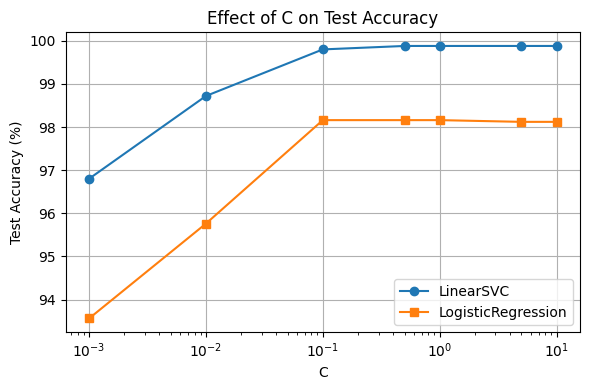

In [35]:
import matplotlib.pyplot as plt

C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

svc_test = [96.80, 98.72, 99.80, 99.88, 99.88, 99.88, 99.88]
log_test = [93.56, 95.76, 98.16, 98.16, 98.16, 98.12, 98.12]

plt.figure(figsize=(6,4))
plt.plot(C_values, svc_test, marker='o', label='LinearSVC')
plt.plot(C_values, log_test, marker='s', label='LogisticRegression')

plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Test Accuracy (%)')
plt.title('Effect of C on Test Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Question-5

##Training on different sizes of train dataset

In [36]:
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import time

# Load data
trn = np.loadtxt('public_trn.txt', dtype=int)
tst = np.loadtxt('public_tst.txt', dtype=int)
X_trn, y_trn = trn[:, :32], trn[:, 32]
X_tst, y_tst = tst[:, :32], tst[:, 32]

X_tst_map = my_map(X_tst)

# Train sizes to try
train_sizes = [100, 250, 500, 750, 1000,
               1500, 2000, 2100,2200,2500,2600,2700, 2800,3500,3800, 4000,
               5000, 6000, 7500]

N_TRIALS = 10
rng = np.random.default_rng(42)

mean_accs = []
std_accs  = []

print(f"{'Size':>6} {'Mean Acc':>10} {'Std':>8} {'Time':>8}")

for n in train_sizes:
    accs = []
    t0 = time.time()

    for trial in range(N_TRIALS):
        # Randomly pick n points from training set
        idx = rng.choice(len(X_trn), size=n, replace=False)
        X_sub   = X_trn[idx]
        y_sub   = y_trn[idx]

        # Map features
        X_sub_map = my_map(X_sub)

        # Train with best params
        clf = LinearSVC(C=0.5, loss='squared_hinge',
                        tol=0.01, max_iter=5000, dual='auto')
        clf.fit(X_sub_map, y_sub)

        # Test on FIXED test set
        acc = accuracy_score(y_tst, clf.predict(X_tst_map))
        accs.append(acc)

    mean_acc = np.mean(accs)
    std_acc  = np.std(accs)
    mean_accs.append(mean_acc)
    std_accs.append(std_acc)

    print(f"{n:>6} {mean_acc*100:>9.2f}% "
          f"{std_acc*100:>7.2f}% "
          f"{time.time()-t0:>7.2f}s")

  Size   Mean Acc      Std     Time
   100     64.00%    1.45%    0.06s
   250     71.43%    1.36%    0.12s
   500     79.05%    0.87%    0.30s
   750     85.21%    0.83%    0.39s
  1000     88.04%    0.71%    0.63s
  1500     92.18%    1.05%    1.09s
  2000     94.69%    0.66%    1.48s
  2100     95.30%    1.03%    0.98s
  2200     95.70%    0.40%    0.85s
  2500     96.76%    0.72%    0.88s
  2600     97.08%    0.53%    0.92s
  2700     97.36%    0.48%    0.95s
  2800     98.17%    0.57%    0.98s
  3500     99.18%    0.36%    1.15s
  3800     99.30%    0.21%    1.25s
  4000     99.53%    0.18%    1.28s
  5000     99.72%    0.12%    1.85s
  6000     99.78%    0.08%    2.63s
  7500     99.88%    0.00%    2.91s


##Plot of Train Size vs Test Accuracy

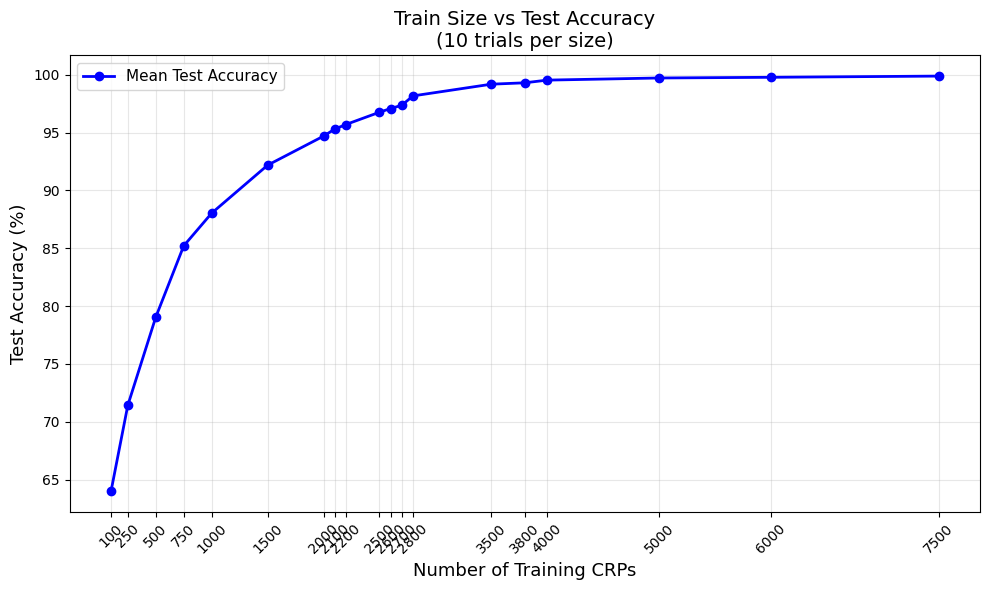

In [37]:
mean_accs = np.array(mean_accs)
std_accs  = np.array(std_accs)

plt.figure(figsize=(10, 6))

# Main curve
plt.plot(train_sizes, mean_accs * 100,
         'b-o', linewidth=2, markersize=6, label='Mean Test Accuracy')

plt.xlabel('Number of Training CRPs', fontsize=13)
plt.ylabel('Test Accuracy (%)', fontsize=13)
plt.title('Train Size vs Test Accuracy\n(10 trials per size)',
          fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(train_sizes, rotation=45)
plt.tight_layout()
plt.savefig('part5_plot.pdf')
plt.show()

##Threshold for 95%, 97% and 99% Test Accuracy

In [38]:
print("\n--- Minimum CRPs for accuracy thresholds ---")
for thresh in [0.95, 0.97, 0.99]:
    for i, n in enumerate(train_sizes):
        if mean_accs[i] >= thresh:
            print(f"≥{thresh*100:.0f}%: needs ~{n} CRPs "
                  f"(achieved {mean_accs[i]*100:.2f}%)")
            break
    else:
        print(f"≥{thresh*100:.0f}%: not achieved in range tested")


--- Minimum CRPs for accuracy thresholds ---
≥95%: needs ~2100 CRPs (achieved 95.30%)
≥97%: needs ~2600 CRPs (achieved 97.08%)
≥99%: needs ~3500 CRPs (achieved 99.18%)
